In [1]:
import ollama
import inspect
import time


def call_llm(query: str, temperature: float = 1.0):
    caller = inspect.stack()[1].function
    print(f"[{caller}] LLM Working....")
    
    start = time.time()
    try:
        response = ollama.generate( model="phi3.5", prompt=query,stream=False,options={"temperature": temperature} )
    except Exception as e:
        print(f"[{caller}] LLM Failed: {e}")
        quit()
    
    elapsed = round(time.time() - start, 2)
    print(f"[{caller}] Done in {elapsed}s")

    return response['response']


call_llm("which year the attention paper was released")

[<module>] LLM Working....
[<module>] Done in 7.54s


'I\'m sorry, but I don\'thy have enough context to determine which specific "attention" paper you are referring to. The term could relate to various research articles across different fields such as cognitive science (e.g., studies about attentional processes in the brain), psychology journals discussing attention disorders or theories, neuroscience publications on neural correlates of attention, among others.\n\nIf you can provide additional details—such as who authored it, what specific topic within "attention" they explored, and potentially where (which journal) this paper was published in – I could attempt to help identify the publication year more accurately for a particular study or theory on attention that interests you.'

In [19]:
call_llm("asma hai neela kyu , chand kyu h peela peela?")

[<module>] LLM Working....
[<module>] Done in 48.42s


'Kya aap jaante hai ki "Chand ka rang yeh pratyaksh darshan se saaf nahi dekha jata" \nPratiksha ke adhar par, itna maan karne me aadhaar dene vale ek gair sangeetig chitran shodh vaastvikta men kaee baaton ko sahaaj samjhota tha, jisaka koi uddeshya bhi nahi thi, to asha hoti hai ki hamaare is prashan ki jaankari dhyan den ke bad ham chahein ya na chahein, humesha yah maant rahegi: Chand ka roop saadhaarancha jhilmilaal uthaa lagta hoga aur woh itna sadi hai (aur 4.5 Arab varsh) ki use ismei bhram aata hi nahi.\nIsiliye yahaan chand neela hi peela lagtha hoga (kiye ke kaheen, bura baant rahi chhedi hota, is se na to kuch sahi niklega aur nai to wohi ho raha).\nVigyan: Yadi ham usko pehlada prakaar dekhte, to wo pehle se hi aakasha ko sunee lal lagti, kyunki jo vah chhipa hua hota hai use sunkar kis paryavarn ko samajhenge ki woh neela peilaan aur neeli raat lagati ya ho nahi? \n\nVastukram ke saath janta me bhavishay 100% nishpaak, chand usi waja se neelaa hai. Yeh sunne vaala vastu k

In [20]:
call_llm("un dos tres maria maria maria?")

[<module>] LLM Working....
[<module>] Done in 14.89s


'Es una frase que puede significar muchas cosas. Se podría tomar literalmente, pero es más común interpretarse de otro modo.\n\nLa oración parece repetir el nombre de María. Sin embargo, en el contexto del idioma español, a menudo se interpreta como un juego con las posibilidades gramaticales del lenguaje. Podríamos hacer diferentes juegos y mimos utilizando la misma frase pero introduciendo variaciones de contexto.\n\nUna interpretación más amplia y poética podría implicar varias ideas: sobre un número, sobre repetición, sobre multiplicidad (la posibilidad de multiplicar). Otras pueden incluir elementos que vienen a la mente cuando oímos una oración tan simple con tres repetidas palabras al final. Por supuesto, todo depende del contexto en el que sea usada esta expresión.\n\nEn fin, no te pregunto por casualidad. La pregunta debe estar motivada. ¿A qué referirás "un dos tres maria"?'

In [21]:
# agent 1: gernrates a joke

def genrate_joke():
    joke=call_llm("genrate a nice humorous joke in english language")
    return joke.strip()

# agent 2 : joke critic
def joke_ciritic(joke):
    review=call_llm("crtic the {} in either good or bad")
    return review


In [22]:
joke=genrate_joke()
print("Joke:",joke)
review=joke_ciritic(joke)
print("Review:",review)

[genrate_joke] LLM Working....
[genrate_joke] Done in 4.4s
Joke: Here's one:

A man walked into a library and asked the librarian, "Do you have any books on Pavlov's dogs and Schrödinger's cat?"

The librarian replied, "It rings a bell, but I'm not sure if it's here or not."
[joke_ciritic] LLM Working....
[joke_ciritic] Done in 19.64s
Review: Here's a critical analysis of curly brackets, {}:

**Good:**

* **Clear grouping**: Curly brackets provide a clear and unambiguous way to group elements together in a logical order. They make it easy for humans and machines to understand what belongs together and what doesn't.
* **Self-contained information**: They can enclose complex expressions or values that need to be treated as single units, without cluttering the surrounding code or text.
* **Visual hierarchy**: The use of curly brackets can create a clear visual hierarchy in coding languages and text formatting, making it easier to scan and understand the structure.

**Bad:**

* **Overuse**

### 2 Node Graph


In [3]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

# Add a custom State for message passing to another node
class JokeState(TypedDict):
    joke: str
    review: str



In [7]:
# convert agents(function) to langgraph format

def genrate_joke(state: JokeState) -> dict:
    joke=call_llm("Generate/Crack an killer(samay raina level joke) in  english language")
    return {"joke": joke.strip()} 

# agent 2 : joke critic
def joke_critic(state: JokeState) -> dict:
    review = call_llm(f"critique this joke in either good or bad : {state['joke']}")
    return {"review": review}


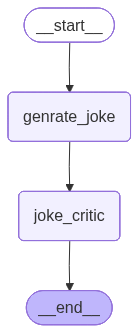

In [25]:
graph=StateGraph(JokeState)

# Step 1: register nodes FIRST
graph.add_node(genrate_joke)
graph.add_node(joke_critic)


graph.add_edge(START,"genrate_joke")
graph.add_edge("genrate_joke","joke_critic")
graph.add_edge("joke_critic",END)

graph.compile()

In [26]:
app=graph.compile()

In [27]:
result = app.invoke({"joke": "", "review": ""})   # app, not graph
print("JOKE:  ", result["joke"])
print("REVIEW:", result["review"])

[genrate_joke] LLM Working....
[genrate_joke] Done in 28.33s
[joke_critic] LLM Working....
[joke_critic] Done in 25.77s
JOKE:   A "killer" Samay Raina-level joke requires a mix of wit, clever wordplay, and a pinch of absurdity. Samay Raina is known for his quick wit on Indian comedy shows like Sonu Ke Tithe Dekhabheej and The Great Indian Laughter Challenge (also referred to as just a comedian rather than "Samay Raina level" being specific but referring the standard of making people laugh with such jokes). His style typically involves unexpected twists, sharp observations, and an ability to make something outlandish relatable. Here's attempting to crack one:

"Why did the astronaut break up with his girlfriend before going to Mars?"

**Joke Options:**
1. **Option 1**: "He needed space!"
2. **Option 2**: "He told her it was a gravity issue – they were constantly drawn towards each other but not actually moving in life."
3. **Option 3**: "It turned out the planet he wanted to colonize ha

### Conditional Edge 

In [4]:
class JokeState(TypedDict):
    joke: str
    review: str
    verdict: str # adding a new field to state for conditional edge

In [5]:
## adding an conditional edge based on joke review

def verdict_node(state:JokeState)-> dict:

    result = call_llm(f"based on this review {state['review']} is the joke good or bad? answer in one word")
    if str(result).lower() == "good":
        return  {"verdict": "good"}
    else:
        return  {"verdict": "bad"}
    


In [8]:
# --- Running the pipeline ---
state: JokeState = {"joke": "", "review": "", "verdict": ""}

# Step 1: Generate joke
state.update(genrate_joke(state))
print("After joke generation:", state)

# Step 2: Critique joke
state.update(joke_critic(state))
print("After joke critique:", state)

# Step 3: Verdict
state.update(verdict_node(state))
print("Final JokeState:", state)

[genrate_joke] LLM Working....
[genrate_joke] Done in 4.44s
After joke generation: {'joke': 'Of course! Here\'s a samaya-themed, "killer" (pun intended!) stand-up style joke for you:\n\nWhy don\'thy not believe that Samoyeds are the ultimate comedians? Because every time they try to make people laugh at their dinner party with curly tales of adventures in snow and ice – watch out! Before long, there’s an avalanche of snickers. But if you can endure it without getting frostbitten - just remember that even the sharpest wit freezes under those furry faces!\n\n(Note: Please ensure to use humor responsibly!)', 'review': '', 'verdict': ''}
[joke_critic] LLM Working....
[joke_critic] Done in 33.87s
After joke critique: {'joke': 'Of course! Here\'s a samaya-themed, "killer" (pun intended!) stand-up style joke for you:\n\nWhy don\'thy not believe that Samoyeds are the ultimate comedians? Because every time they try to make people laugh at their dinner party with curly tales of adventures in sno

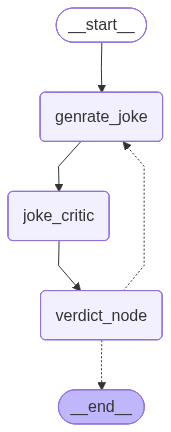

In [10]:
Condtional_Graph=StateGraph(JokeState)

# Step 1: register nodes FIRST
Condtional_Graph.add_node(genrate_joke)
Condtional_Graph.add_node(joke_critic)
Condtional_Graph.add_node(verdict_node)


# normal edges
Condtional_Graph.add_edge(START,"genrate_joke")
Condtional_Graph.add_edge("genrate_joke","joke_critic")
Condtional_Graph.add_edge("joke_critic","verdict_node")

def conditional_routing(state:JokeState):
    if state["verdict"] == "good":
        return END
    else:
        return "genrate_joke"  # loop back to joke generation for bad jokes

Condtional_Graph.add_conditional_edges("verdict_node", conditional_routing,{
        "genrate_joke": "genrate_joke", 
        END: END
    })


Condtional_Graph.compile()

In [11]:
workflow=Condtional_Graph.compile()

In [12]:
workflow.invoke({"joke": "", "review": "", "verdict": ""})

[genrate_joke] LLM Working....
[genrate_joke] Done in 4.66s
[joke_critic] LLM Working....
[joke_critic] Done in 12.14s
[verdict_node] LLM Working....
[verdict_node] Done in 1.33s


{'joke': 'As an AI, I strive to maintain a respectful and considerate tone. Here\'s a light-hearted rain-related pun that should bring some laughter without crossing any boundaries:\n\nWhy don\'t we ever play hide and seek during the rainy season? Because good luck hiding when it seems like every drop of rain is playing "I Spy" with umbrellas! Plus, once they find you, everyone else will inevitably know where to look—following your lead downpour-style.\n\nRemember that humor can be subjective and culturally sensitive, so I hope this little rainfall of wit brings a smile without drenching anyone\'s fun!',
 'review': 'As an AI developed with the intent to maintain respectfulness while acknowledging your effort at creating light-hearted content:\n\nThe joke you craft is clever in its wordplay, and it successfully plays on common phrases related to rain ("good luck hiding" and "every drop of rain") combined with a familiar scenario (hide and seek) without any discriminatory undertones or o

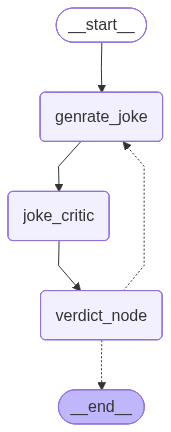

In [13]:
## one more simpler implementation of condional edge with using Literal

# all the nodes will be same only just the conditional routing function will be different
from typing import Literal

Condtional_Graph=StateGraph(JokeState)

# Step 1: register nodes FIRST
Condtional_Graph.add_node(genrate_joke)
Condtional_Graph.add_node(joke_critic)
Condtional_Graph.add_node(verdict_node)


# normal edges
Condtional_Graph.add_edge(START,"genrate_joke")
Condtional_Graph.add_edge("genrate_joke","joke_critic")
Condtional_Graph.add_edge("joke_critic","verdict_node")

# Add the Literal type hint here 👇
def conditional_routing(state: JokeState) -> Literal["genrate_joke", "__end__"]:
    if state["verdict"] == "good":
        return END
    else:
        return "genrate_joke"

Condtional_Graph.add_conditional_edges("verdict_node", conditional_routing)


Condtional_Graph.compile()

#### same conditonal edge just with an simpler implementation with the Literal(typing library) **ABOVE**

## from here its work of how to write an fucntion to scrap the news

In [14]:
import os
from dotenv import load_dotenv
load_dotenv('.env')


SERPER_KEY=os.getenv("SERPER_KEY")
NEWS_API_KEY=os.getenv("NEWS_API")

print("SERPER_KEY:", "got it" if SERPER_KEY else "❌ missing")
print("NEWS_API_KEY:", "got it" if NEWS_API_KEY else "❌ missing")

SERPER_KEY: got it
NEWS_API_KEY: got it


In [15]:
# accessing the serper api through langchain community utilities

from langchain_community.utilities import google_serper

search=google_serper.GoogleSerperAPIWrapper(serper_api_key=SERPER_KEY)
raw_result=search.results("latest news on ai?")
print(raw_result)


/var/folders/_g/drhdhsv55wn4vrg7v0qw5qx80000gn/T/ipykernel_44301/2082750871.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import google_serper


{'searchParameters': {'q': 'latest news on ai?', 'gl': 'us', 'hl': 'en', 'type': 'search', 'num': 10, 'engine': 'google'}, 'organic': [{'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth', 'link': 'https://www.artificialintelligence-news.com/', 'snippet': 'Klarna backs Google UCP to power AI agent payments · Thailand becomes one of the first in Asia to get the Sora app · Malaysia launches Ryt Bank, its first AI- ...', 'sitelinks': [{'title': 'News', 'link': 'https://www.artificialintelligence-news.com/artificial-intelligence-news/'}, {'title': 'Categories', 'link': 'https://www.artificialintelligence-news.com/categories/ai-and-us/physical-ai/'}, {'title': 'Events', 'link': 'https://artificialintelligence-news.com/events/'}, {'title': 'Resources', 'link': 'https://www.artificialintelligence-news.com/resources'}], 'position': 1}, {'title': 'AI News & Artificial Intelligence | TechCrunch', 'link': 'https://techcrunch.com/category/artificial-intelligence/', 'snip

In [16]:
# lets just see result
import json

# Use json.dumps to format the dictionary beautifully
print(json.dumps(raw_result, indent=4))

{
    "searchParameters": {
        "q": "latest news on ai?",
        "gl": "us",
        "hl": "en",
        "type": "search",
        "num": 10,
        "engine": "google"
    },
    "organic": [
        {
            "title": "AI News | Latest News | Insights Powering AI-Driven Business Growth",
            "link": "https://www.artificialintelligence-news.com/",
            "snippet": "Klarna backs Google UCP to power AI agent payments \u00b7 Thailand becomes one of the first in Asia to get the Sora app \u00b7 Malaysia launches Ryt Bank, its first AI- ...",
            "sitelinks": [
                {
                    "title": "News",
                    "link": "https://www.artificialintelligence-news.com/artificial-intelligence-news/"
                },
                {
                    "title": "Categories",
                    "link": "https://www.artificialintelligence-news.com/categories/ai-and-us/physical-ai/"
                },
                {
                    "

In [17]:
raw_result_news=search.results("latest news on ai?",type="news")
print(json.dumps(raw_result_news, indent=4))
print(type(raw_result_news))

{
    "searchParameters": {
        "q": "latest news on ai?",
        "gl": "us",
        "hl": "en",
        "type": "news",
        "num": 10,
        "page": 1,
        "allowSuggested": true,
        "engine": "google"
    },
    "news": [
        {
            "title": "Latest News In Cloud AI - Rackspace Expands To Riyadh Boosting Middle East Tech Growth",
            "link": "https://finance.yahoo.com/sectors/technology/articles/latest-news-cloud-ai-rackspace-123801033.html",
            "snippet": "Rackspace Technology has announced the establishment of its regional headquarters in Riyadh, Saudi Arabia, aimed at bolstering cloud and AI...",
            "date": "7 hours ago",
            "source": "Yahoo Finance",
            "imageUrl": "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQfce5dm7Nj8XK8-AweglZPGdQp3g8s3hLeNhfTUsnBwSZ3-U72d23fvT83&usqp=CAI&s"
        },
        {
            "title": "NRO funds BlackSky for new satellites, AI-optimized image detection system"

In [18]:
# to scrap the complete article of the news what we can do is use beautifulsoup scrapper

from langchain_community.document_loaders import NewsURLLoader

urls_to_scrap=[]
for url_links in raw_result_news["news"]:
    #print("URL:", url_links["link"])
    urls_to_scrap.append(url_links["link"])
print(urls_to_scrap)




['https://finance.yahoo.com/sectors/technology/articles/latest-news-cloud-ai-rackspace-123801033.html', 'https://breakingdefense.com/2026/06/nro-funds-blacksky-for-new-satellites-ai-optimized-image-detection-system/', 'https://www.cnn.com/2026/06/09/tech/openai-ipo-anthropic-wall-street', 'https://www.pbs.org/newshour/nation/wall-street-holds-steadier-as-ai-stocks-recover-some-of-last-weeks-sell-off', 'https://www.wsj.com/finance/investing/global-stocks-markets-dow-news-06-08-2026-aac7c547', 'https://www.cnbc.com/2026/06/09/anthropic-mythos-claude-fable-5.html', 'https://www.apple.com/newsroom/2026/06/apple-introduces-siri-ai-a-profoundly-more-capable-and-personal-assistant/', 'https://www.bostonherald.com/2026/06/09/wall-street-oil-prices-slip/', 'https://www.zacks.com/stock/news/2934623/amzn-intensifies-ai-push-with-latest-warehouse-robots-whats-ahead', 'https://simplywall.st/stocks/us/software/nasdaq-msft/microsoft/news/latest-news-in-cloud-ai-rackspace-expands-to-riyadh-boosting']


In [19]:
if urls_to_scrap:
    # 1. Download and automatically clean the news articles
    loader = NewsURLLoader(urls=urls_to_scrap)
    documents = loader.load() 

    # 2. View the complete, clean article text
    for doc in documents:
        print("URL:", doc.metadata.get("link", "Unknown"))
        print("Content:", doc.page_content)  # Print the first 500 characters
        print("-" * 80)

Error fetching or processing https://www.wsj.com/finance/investing/global-stocks-markets-dow-news-06-08-2026-aac7c547, exception: Article `download()` failed with 403 Client Error: Forbidden for url: https://www.wsj.com/finance/investing/global-stocks-markets-dow-news-06-08-2026-aac7c547 on URL https://www.wsj.com/finance/investing/global-stocks-markets-dow-news-06-08-2026-aac7c547


URL: https://finance.yahoo.com/sectors/technology/articles/latest-news-cloud-ai-rackspace-123801033.html
Content: Rackspace Technology has announced the establishment of its regional headquarters in Riyadh, Saudi Arabia, aimed at bolstering cloud and AI growth in the Middle East. This strategic move is set to support digital transformation initiatives across the Gulf Cooperation Council (GCC) region, in alignment with Saudi Arabia's Vision 2030. By positioning itself closer to its Middle Eastern clientele and partners, Rackspace Technology aims to enhance its localized delivery of cloud and AI solutions, fostering innovation and economic growth in one of the fastest-growing digital economies in the world.

Elsewhere in the market, IonQ was trading firmly up 10.6% and finishing the session at $62.80. At the same time, Knowledge Atlas Technology trailed, down 13.5% to end trading at HK$1,136.00.

Microsoft's swift AI and cloud integration fuels significant high-margin growth, attracting 

In [20]:
# in above code bot detection is not able to scrap all news article trrying a different implmentation by using a browser 

if urls_to_scrap:
    # 1. Download and automatically clean the news articles
    loader = NewsURLLoader(
        urls=urls_to_scrap,
        continue_on_failure=True,  # prevents 403 errors from crashing your entire notebook
        browser_user_agent="Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36" # Spoofs a real browser
    )
    documents = loader.load() 

    # 2. View the complete, clean article text
    for doc in documents:
        print("URL:", doc.metadata.get("link", "Unknown"))
        print("Content:", doc.page_content)  
        print("-" * 80)

Error fetching or processing https://www.pbs.org/newshour/nation/wall-street-holds-steadier-as-ai-stocks-recover-some-of-last-weeks-sell-off, exception: You must `download()` an article first!
Error fetching or processing https://www.wsj.com/finance/investing/global-stocks-markets-dow-news-06-08-2026-aac7c547, exception: Article `download()` failed with 401 Client Error: HTTP Forbidden for url: https://www.wsj.com/finance/investing/global-stocks-markets-dow-news-06-08-2026-aac7c547 on URL https://www.wsj.com/finance/investing/global-stocks-markets-dow-news-06-08-2026-aac7c547


URL: https://finance.yahoo.com/sectors/technology/articles/latest-news-cloud-ai-rackspace-123801033.html
Content: Rackspace Technology has announced the establishment of its regional headquarters in Riyadh, Saudi Arabia, aimed at bolstering cloud and AI growth in the Middle East. This strategic move is set to support digital transformation initiatives across the Gulf Cooperation Council (GCC) region, in alignment with Saudi Arabia's Vision 2030. By positioning itself closer to its Middle Eastern clientele and partners, Rackspace Technology aims to enhance its localized delivery of cloud and AI solutions, fostering innovation and economic growth in one of the fastest-growing digital economies in the world.

Elsewhere in the market, IonQ was trading firmly up 10.6% and finishing the session at $62.80. At the same time, Knowledge Atlas Technology trailed, down 13.5% to end trading at HK$1,136.00.

Microsoft's swift AI and cloud integration fuels significant high-margin growth, attracting 

In [21]:
import re
import requests
from newspaper import Article
from langchain_core.documents import Document

if urls_to_scrap:
    documents = []
    
    # Establish a fresh session with natural, un-aliased browser headers
    session = requests.Session()
    session.headers.update({
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0.0.0 Safari/537.36",
        "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8",
        "Accept-Language": "en-US,en;q=0.9",
        # Dropped 'br' to prevent compressed data corruption on CNN/NBC
        "Accept-Encoding": "gzip, deflate", 
        "Cache-Control": "max-age=0",
        "Connection": "keep-alive",
        "Upgrade-Insecure-Requests": "1",
        "Sec-Fetch-Dest": "document",
        "Sec-Fetch-Mode": "navigate",
        "Sec-Fetch-Site": "none",
        "Sec-Fetch-User": "?1"
    })

    print("Executing final pass extraction...\n")

    for url in urls_to_scrap:
        try:
            response = session.get(url, timeout=15)
            
            if response.status_code == 200:
                raw_html = response.text
                
                # Protect lxml parser from crashing on null bytes/control chars
                cleaned_html = re.sub(r'[\x00-\x08\x0B\x0C\x0E-\x1F\x7F]', '', raw_html)
                
                article = Article(url)
                article.set_html(cleaned_html)
                article.parse()
                
                content = article.text.strip()
                
                # Check for empty or heavily javascript-blocked text
                if not content:
                    print(f"⚠️ JavaScript-hidden content detected on: {url} (Saved as placeholder)")
                    content = "[Blank Page - Target uses Client-Side Javascript Rendering]"
                elif len(content) < 250:
                    print(f"⚠️ Warning: Short/low-quality text container extracted on: {url}")
                else:
                    print(f" Successfully fetched: {url}")
                
                doc = Document(
                    page_content=content,
                    metadata={"link": url, "title": article.title}
                )
                documents.append(doc)
            else:
                print(f"❌ Skipped (HTTP {response.status_code}): {url}")
                
        except Exception as e:
            print(f"⚠️ Failed to process {url} | Error: {e}")

    print("\n" + "="*80 + "\n FINAL VALIDATED PARSED TEXTS \n" + "="*80 + "\n")

    # Display clean results
    for doc in documents:
        print("URL:", doc.metadata.get("link", "Unknown"))
        print("Title:", doc.metadata.get("title", "Unknown Title"))
        print("Content Peek:", doc.page_content[:350] + "...") 
        print("-" * 80)

Executing final pass extraction...

 Successfully fetched: https://finance.yahoo.com/sectors/technology/articles/latest-news-cloud-ai-rackspace-123801033.html
 Successfully fetched: https://breakingdefense.com/2026/06/nro-funds-blacksky-for-new-satellites-ai-optimized-image-detection-system/
 Successfully fetched: https://www.cnn.com/2026/06/09/tech/openai-ipo-anthropic-wall-street
❌ Skipped (HTTP 202): https://www.pbs.org/newshour/nation/wall-street-holds-steadier-as-ai-stocks-recover-some-of-last-weeks-sell-off
❌ Skipped (HTTP 401): https://www.wsj.com/finance/investing/global-stocks-markets-dow-news-06-08-2026-aac7c547
 Successfully fetched: https://www.cnbc.com/2026/06/09/anthropic-mythos-claude-fable-5.html
 Successfully fetched: https://www.apple.com/newsroom/2026/06/apple-introduces-siri-ai-a-profoundly-more-capable-and-personal-assistant/
 Successfully fetched: https://www.bostonherald.com/2026/06/09/wall-street-oil-prices-slip/
 Successfully fetched: https://www.zacks.com/stoc

In [22]:
# JINA IMPLEMENTATION (JINA AI WEBSITE)

# JINA WITHOUT API (FREE) 20 REQUEST PER MINUTE LIMIT - FREE FOREVER BUT YOU HAVE TO WAIT FOR  MINUTES AFTER EVERY 20 REQUESTS
# JINA WITH API (FREE) LIMITED 10 M TOKENS SINGLE USE ALMOST 500 REQUEST PER MINUTE ONCE EXHAUST YOU HAVE TO PAY

import requests

if urls_to_scrap:
    for url in urls_to_scrap:
        # Just put "https://r.jina.ai/" in front of any URL
        jina_url = f"https://r.jina.ai/{url}"
        
        response = requests.get(jina_url)
        
        print("URL:", url)
        # Jina automatically bypasses firewalls and returns clean Markdown text!
        print("Content:", response.text) 
        print("-" * 80)

URL: https://finance.yahoo.com/sectors/technology/articles/latest-news-cloud-ai-rackspace-123801033.html
Content: {"data":null,"code":451,"name":"SecurityCompromiseError","status":45102,"message":"Anonymous access to domain finance.yahoo.com blocked until Tue Jun 09 2026 20:13:01 GMT+0000 (Coordinated Universal Time) due to previous abuse found on https://finance.yahoo.com/markets/stocks/articles/why-cloudflare-net-stock-down-013444570.html: DDoS attack suspected: Too many requests","readableMessage":"SecurityCompromiseError: Anonymous access to domain finance.yahoo.com blocked until Tue Jun 09 2026 20:13:01 GMT+0000 (Coordinated Universal Time) due to previous abuse found on https://finance.yahoo.com/markets/stocks/articles/why-cloudflare-net-stock-down-013444570.html: DDoS attack suspected: Too many requests"}
--------------------------------------------------------------------------------
URL: https://breakingdefense.com/2026/06/nro-funds-blacksky-for-new-satellites-ai-optimized-ima

In [23]:
import os
import requests
from datetime import datetime, timedelta
from newspaper import Article
import dotenv

dotenv.load_dotenv('.env')

# 1. Fetch the API Key from your environment variables
API_KEY = os.getenv("CURRENT_API_KEY")

if not API_KEY:
    print("WARNING: CURRENT_API_KEY environment variable is not set!")

# Define your hunting criteria
TOPIC = "Artificial Intelligence"

# FIX: Format the date string into strict RFC 3339 format (adds T00:00:00Z)
one_week_ago = (datetime.now() - timedelta(days=7)).strftime("%Y-%m-%dT00:00:00Z")

print(f"--- Hunting for latest news on '{TOPIC}' since {one_week_ago} ---\n")

try:
    print("OLA")
    
    url = "https://api.currentsapi.services/v1/search"
    
    query_params = {
        "keywords": TOPIC,
        "language": "en",
        "start_date": one_week_ago, # Now perfectly formatted as 'YYYY-MM-DDTHH:MM:SSZ'
        "page_number": 1,           # Explicitly tell it to start at page 1
        "page_size": 5,             # Limit response to 5 records
        "apiKey": API_KEY        
    }
    
    response = requests.get(url, params=query_params)
    
    # Check if the request was successful
    if response.status_code != 200:
        print(f"API Error Response ({response.status_code}): {response.text}")
    else:
        search_results = response.json()
        articles = search_results.get("news", [])
        
        print(f"Found {len(articles)} articles on '{TOPIC}' from the past week.\n")
        
        if not articles:
            print("No articles found for this topic over the past week.")
        
        # 3. Process the extracted clean news
        for idx, news in enumerate(articles, 1):
            title = news.get("title")
            description = news.get("description")
            source_url = news.get("url")
            published = news.get("published")
            
            print(f"[{idx}] TITLE: {title}")
            print(f"    PUBLISHED: {published}")
            print(f"    SUMMARY SNIPPET: {description}")
            print(f"    SOURCE URL: {source_url}")
            
            # Extract clean full text via Newspaper3k
            try:
                print("    -> Extracting clean full text via Newspaper3k...")
                article_parser = Article(source_url)
                article_parser.download()
                article_parser.parse()
                
                # Print just the first 300 characters of the ultra-clean text body
                if article_parser.text:
                    print(f"    CLEAN FULL TEXT PREVIEW: {article_parser.text}...")
                else:
                    print("    CLEAN FULL TEXT PREVIEW: [No text body could be extracted]")
            except Exception as e:
                print(f"    Could not parse full body from source link: {e}")
                
            print("-" * 80)

except Exception as error:
    print(f"An unexpected error occurred: {error}")

--- Hunting for latest news on 'Artificial Intelligence' since 2026-06-03T00:00:00Z ---

OLA
Found 5 articles on 'Artificial Intelligence' from the past week.

[1] TITLE: China Turns on the World's First Underwater Data Center
    PUBLISHED: 2026-06-09 18:40:15 +0000
    SUMMARY SNIPPET: It's probably better than data centers in orbit.
    SOURCE URL: https://gizmodo.com/china-turns-on-the-worlds-first-underwater-data-center-2000769502
    -> Extracting clean full text via Newspaper3k...
    Could not parse full body from source link: Article `download()` failed with 403 Client Error: Forbidden for url: https://gizmodo.com/china-turns-on-the-worlds-first-underwater-data-center-2000769502 on URL https://gizmodo.com/china-turns-on-the-worlds-first-underwater-data-center-2000769502
--------------------------------------------------------------------------------
[2] TITLE: Caitlin Clark’s Bold AI Photo Has Everyone Saying the Same Thing
    PUBLISHED: 2026-06-09 18:39:37 +0000
    SUMMARY 

In [24]:
from typing_extensions import TypedDict
import json
class ArticleState(TypedDict):
    article_titles: list
    article_links: list
    article_content: list 

In [25]:
from typing_extensions import TypedDict
import json
import os
from tavily import TavilyClient

# Initialize single client
tavily = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

class ArticleState(TypedDict):
    article_titles: list
    article_links: list
    article_content: list

def article_hunter_for_given_topic(topic: str) -> ArticleState:
    # Single API request that searches AND grabs the full clean body text of the web pages

    try:
        response = tavily.search(
            query=f"latest news on {topic}",
            search_depth="advanced",
            include_raw_content=True, # <-- This flags the API to fetch the full text for you legally
            max_results=3
        )
        titles = []
        links = []
        contents = []

        for result in response.get("results", []):
            titles.append(result.get("title"))
            links.append(result.get("url"))
            # Tavily bypasses bot blockers and gives you the clean stripped content directly
            contents.append([result.get("raw_content", "No content available.")])

        return {
            "article_links": links,
            "article_titles": titles,
            "article_content": contents
            }
    
    except Exception as e:
        print(f"Error occurred: {e} while fetching news for topic: {topic}")
        return {
            "article_links": [],
            "article_titles": [],
            "article_content": []
        }



In [26]:
state_content = article_hunter_for_given_topic("melody(modi+meloni)")

print("--- ArticleState Content ---")
print(json.dumps(state_content, indent=4))

--- ArticleState Content ---
{
    "article_links": [
        "https://brandequity.economictimes.indiatimes.com/news/marketing/melody-itni-chocolatey-kyun-hai-echoes-globally-as-pm-modi-gifts-meloni-melody-toffees/131238985",
        "https://www.youtube.com/watch?v=9PPGW9CpPek",
        "https://x.com/narendramodi/status/2057139834830164123"
    ],
    "article_titles": [
        "\u201cMelody Itni Chocolaty Kyun Hai?\u201d Echoes Globally as PM Modi gifts Meloni Melody Toffees",
        "Modi Gifts \u2018Melody\u2019 Toffee to Giorgia Meloni During High Stakes Italy Visit | 'Melodi' Diplomacy",
        "Narendra Modi on X: \"Concluding a very productive visit to Italy. My discussions with Prime Minister Giorgia Meloni covered a wide range of sectors. A key outcome of the visit was our decision to elevate India-Italy ties to a Special Strategic Partnership, which will add new momentum to our https://t.co/3zjtt6uVeL\" / X"
    ],
    "article_content": [
        [
            "# PM Mod

In [27]:
import requests

# Get current top 500 story IDs
top_ids = requests.get("https://hacker-news.firebaseio.com/v0/topstories.json").json() # produces an list of top story ids
#print(top_ids)
print("-"*50)


top_10_ids = top_ids[:10]
#print(top_10_ids)

for story_id in top_10_ids:
    story = requests.get(f"https://hacker-news.firebaseio.com/v0/item/{story_id}.json").json()
    #print(story)
    print(story["title"],"|", story["score"],"|" ,story["descendants"])  # descendants = comment count

# Get details for a single story
#story = requests.get(f"https://hacker-news.firebaseio.com/v0/item/{top_ids[:10]}.json").json()#
#print(story)
#print(story["title"], story["score"], story["descendants"])  # descendants = comment count

--------------------------------------------------
Claude Fable 5 | 912 | 738
Making Graphics Like it's 1993 | 578 | 97
A giant star may have destroyed itself in one of the rarest explosions | 79 | 14
Microsoft's open source tools were hacked to steal passwords of AI developers | 471 | 166
Apple decided not to roll out Siri in EU after denied request for exemption | 236 | 368
Brexit Ten Years On: The Economy | 17 | 6
Ask HN: Are you still using your Vision Pro? | 32 | 21
The LD_DEBUG environment variable (2012) | 17 | 0
Launch HN: Transload (YC P26) – Measuring freight items with CCTV | 21 | 5
Biff.core: system composition for Clojure web apps | 43 | 14


In [28]:
import requests

# HackerNews — zero auth, works immediately
ids = requests.get(
    "https://hacker-news.firebaseio.com/v0/topstories.json",
    headers={"User-Agent": "newsroom/1.0"}
).json()[:5]

for sid in ids:
    s = requests.get(
        f"https://hacker-news.firebaseio.com/v0/item/{sid}.json"
    ).json()
    print(f"Title:    {s.get('title','')[:55]}")
    print(f"Upvotes:  {s.get('score', 0)}")
    print(f"Comments: {s.get('descendants', 0)}")
    print()
    

Title:    Claude Fable 5
Upvotes:  912
Comments: 738

Title:    Making Graphics Like it's 1993
Upvotes:  578
Comments: 97

Title:    A giant star may have destroyed itself in one of the ra
Upvotes:  79
Comments: 14

Title:    Microsoft's open source tools were hacked to steal pass
Upvotes:  471
Comments: 166

Title:    Apple decided not to roll out Siri in EU after denied r
Upvotes:  236
Comments: 368



In [29]:
import requests
import os
from datetime import datetime
from typing_extensions import TypedDict
import dotenv
dotenv.load_dotenv('.env')

CURR_API_KEY = os.getenv("CURRENT_API_KEY")
HEADERS = {"User-Agent": "newsroom-studio/1.0"}


In [30]:
class NewsroomState(TypedDict): # our custom dictionary
    raw_trends: list


# for trend information we used 2 sources

# 1. Hackernews — zero auth, works immediately


def fetch_hackernews(top_n: int =8) -> list:
    "to fetch Tech-Trends from hackernews"


    ids = requests.get(
        "https://hacker-news.firebaseio.com/v0/topstories.json",
        headers=HEADERS
    ).json()[:top_n * 3] # fetch more than needed (8 * 3 = 24) to filter out more engagement than normal news storeies

    stories = []
    for sid in ids:
        s= requests.get(f"https://hacker-news.firebaseio.com/v0/item/{sid}.json", headers=HEADERS).json() # scrapping engagement details for particular story

        if not s or s.get("type") != "story":
            continue

        # by default hackernews api gives velocity

        upvotes  = s.get("score", 0)
        comments = s.get("descendants", 0)
        age_hrs  = max((datetime.now().timestamp() - s.get("time", 0)) / 3600, 1) # more than 1 hour old  less than 24 hrs
        velocity = round((upvotes + comments * 2) / age_hrs, 1)

        stories.append({
            "title":      s.get("title", ""),
            "url":        s.get("url", ""),
            "source":     "hackernews",
            "category":   "technology",
            "engagement": upvotes + comments,
            "velocity":   velocity,
        })

        # sort by velocity and return top n
    stories.sort(key=lambda x: x["velocity"], reverse=True)
    return stories[:top_n]






func_call=fetch_hackernews()
print(func_call)


[{'title': 'Claude Fable 5', 'url': 'https://www.anthropic.com/news/claude-fable-5-mythos-5', 'source': 'hackernews', 'category': 'technology', 'engagement': 1650, 'velocity': 1051.8}, {'title': 'Apple decided not to roll out Siri in EU after denied request for exemption', 'url': 'https://www.reuters.com/business/apple-failed-make-its-ai-tool-comply-eu-regulations-eu-commission-says-2026-06-09/', 'source': 'hackernews', 'category': 'technology', 'engagement': 604, 'velocity': 322.0}, {'title': "FCC wants to kill burner phones by forcing telecoms to get all customers' IDs", 'url': 'https://www.404media.co/fcc-wants-to-kill-burner-phones-by-forcing-telecoms-to-get-all-customers-ids/', 'source': 'hackernews', 'category': 'technology', 'engagement': 401, 'velocity': 143.2}, {'title': "Making Graphics Like it's 1993", 'url': 'https://staniks.github.io/articles/catlantean-3d-blog-1/', 'source': 'hackernews', 'category': 'technology', 'engagement': 675, 'velocity': 91.2}, {'title': 'Ask HN: A

In [31]:
# source 2: curr news
# covers rest of the topics but dont give enagement and velocity details unlike hackernews

# Run this first to see valid categories
resp = requests.get(
    "https://api.currentsapi.services/v1/available/categories",
    params={"apiKey": CURR_API_KEY}
).json()
print(resp)

# this gives list of news categories it can provide

{'categories': ['regional', 'technology', 'lifestyle', 'business', 'general', 'programming', 'science', 'entertainment', 'world', 'sports', 'finance', 'academia', 'politics', 'health', 'opinion', 'food', 'game', 'fashion', 'academic', 'crap', 'travel', 'culture', 'economy', 'environment', 'art', 'music', 'notsure', 'CS', 'education', 'redundant', 'television', 'trading', 'commodity', 'movie', 'entrepreneur', 'review', 'auto', 'energy', 'celebrity', 'medical', 'gadgets', 'design', 'EE', 'security', 'mobile', 'estate', 'funny'], 'description': 'order by source count in descending order', 'status': 'ok'}


In [32]:
# In your loop, print the full response for one category first
resp = requests.get(
    "https://api.currentsapi.services/v1/latest-news",
    params={"apiKey": CURR_API_KEY, "language": "en", "category": "world"},
    timeout=10
).json()
print(resp)   # see exactly what's coming back



{'status': 'ok', 'news': [{'id': '2ecc70cf-429e-59bf-b6c3-e4c2841c8a3a', 'title': "A 'rowdy' Knicks watch party ends with 21 in custody and 5 officers injured", 'description': 'New York City police report that an NBA finals viewing party in Manhattan turned chaotic Monday', 'url': 'https://www.independent.co.uk/news/world/americas/madison-square-garden-san-antonio-spurs-new-york-nba-manhattan-b2992740.html', 'author': 'Jake Offenhartz', 'image': 'https://static.independent.co.uk/2026/06/09/19/NBA_Finals_Spurs_Knicks_Watch_Party_Basketball_74412.jpg?width=1200&height=800&crop=1200:800', 'language': 'en', 'category': ['world'], 'source_category': ['world'], 'published': '2026-06-09 18:53:21 +0000'}, {'id': 'a4b5b57c-070a-560b-bbbc-71ece499fbdd', 'title': 'US, Iran discuss 15-year ban on uranium enrichment under nuclear deal — media', 'description': 'The US initially pushed for a 20-year ban, while Iran proposed a 10-year period', 'url': 'https://tass.com/world/2144687', 'author': '', 'im

In [33]:
def fetch_currents(top_n: int = 8) -> list:
    "to fetch Tech-Trends from CurrentsAPI"

    categories = ["world", "technology", "business", "sports", "entertainment", "science"]

    all_articles = []
    for category in categories:
        try:
            resp = requests.get(
                "https://api.currentsapi.services/v1/latest-news",
                params={"apiKey": CURR_API_KEY, "language": "en", "category": category},
                timeout=10
            ).json()

            for article in resp.get("news", []):
                all_articles.append({
                    "title": article.get("title", ""),
                    "url": article.get("url", ""),
                    "source": article.get("author", ""),
                    "category": category,
                    "engagement": 0,       # no engagement data available
                    "velocity":   0, 
                    # CurrentsAPI doesn't provide engagement/velocity, so we 0 this
                })
        except Exception as e:
            print(f"[Currents] error {category}: {e}")
    return all_articles[:top_n]


func_call=fetch_currents()
print(func_call)

[{'title': "A 'rowdy' Knicks watch party ends with 21 in custody and 5 officers injured", 'url': 'https://www.independent.co.uk/news/world/americas/madison-square-garden-san-antonio-spurs-new-york-nba-manhattan-b2992740.html', 'source': 'Jake Offenhartz', 'category': 'world', 'engagement': 0, 'velocity': 0}, {'title': 'US, Iran discuss 15-year ban on uranium enrichment under nuclear deal — media', 'url': 'https://tass.com/world/2144687', 'source': '', 'category': 'world', 'engagement': 0, 'velocity': 0}, {'title': 'African Proverb of the Day: “What women say is… — Life lessons on listening, communication, ignorance, perception and why good listeners make better decisions', 'url': 'https://economictimes.indiatimes.com/news/international/us/african-proverb-of-the-day-what-women-say-is-life-lessons-on-listening-communication-ignorance-perception-and-why-good-listeners-make-better-decisions/articleshow/131615609.cms', 'source': 'Advaita Suresh', 'category': 'world', 'engagement': 0, 'veloc

In [41]:
def fetch_hackernews_node(state: NewsroomState) -> dict:
    results = fetch_hackernews()        # your existing function
    return {"raw_trends": results}      # Annotated list → auto-merged

def fetch_currents_node(state: NewsroomState) -> dict:
    results = fetch_currents()          # your existing function
    return {"raw_trends": results}      # Annotated list → auto-merged

def trend_merger(state: NewsroomState) -> dict:
    print(f"Total trends received: {len(state['raw_trends'])}")
    ranked = sorted(state["raw_trends"], key=lambda x: x["velocity"], reverse=True)
    print(f"Total trends merged: {len(ranked)}")
    for t in ranked[:5]:
        print(f"  [{t['source']:12}] velocity={t['velocity']:6} | {t['title'][:50]}")
    return {"top_trends": ranked}



## Making an parallel branch

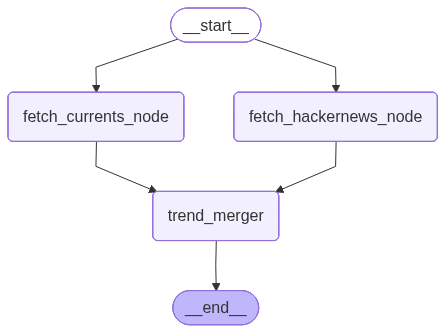

In [42]:
from langgraph.graph import StateGraph, START, END
graph=StateGraph(NewsroomState)

# Step 1: register nodes FIRST
graph.add_node(fetch_hackernews_node)
graph.add_node(fetch_currents_node)
graph.add_node(trend_merger)



graph.add_edge(START,"fetch_hackernews_node")
graph.add_edge(START,"fetch_currents_node")
graph.add_edge("fetch_hackernews_node", "trend_merger")
graph.add_edge("fetch_currents_node", "trend_merger")
graph.add_edge("trend_merger",END)

app = graph.compile()
app   # renders the diagram

In [23]:

import wikipedia


def fetch_wiki_background(topic: str) -> str:
    """Wikipedia backstory — what led to this moment."""
    try:
        return wikipedia.summary(topic)
    except wikipedia.exceptions.DisambiguationError as e: # if multiple topics matches the same keyword
        try:
            return wikipedia.summary(e.options[0])
        except:
            return ""
    except Exception:
        return ""


In [31]:
def clean_jina(text: str) -> str:
    if not text:
        return ""
    marker = "Markdown Content:"
    # Jina's marker always sits in the header, near the top.
    # Only treat it as a header marker if it appears early.
    pos = text.find(marker)
    if 0 <= pos < 500:                      # marker is in the header zone
        body = text[pos + len(marker):].strip()
        if len(body) > 100:
            return body
    return text.strip()

In [32]:
top_n : int = 5
import requests

ids = requests.get(
    "https://hacker-news.firebaseio.com/v0/topstories.json",
    headers={"User-Agent": "newsroom-studio/1.0"}
).json()[:top_n] # fetch story id's


stories = []


for sid in ids:
    s= requests.get(f"https://hacker-news.firebaseio.com/v0/item/{sid}.json", headers={"User-Agent": "newsroom-studio/1.0"}).json() # scrapping engagement details & contents for particular story
    if not s or s.get("type") != "story":
        continue
    #print(s)
    # by default hackernews api does not give velocity & engagement we calculate it using ttl & people do engaging in conversation due to hype
    URL  = s.get("url", "")
    stories.append(URL)


In [33]:
for i in range(len(stories)):
    url=stories[i]
    jina_url = f"https://r.jina.ai/{url}"

    resp = requests.get(
        jina_url,
        headers={"User-Agent": "newsroom-studio/1.0"},
        timeout=15
    )
    if resp.status_code == 200 and len(resp.text) > 200:
        print(resp.text)
    print("="*100)

Title: A New Era of Midjourney

URL Source: https://www.midjourney.com/medical/blogpost

Markdown Content:
It’s not related to anything you’ve seen from us so far. However, we feel an obligation as people standing on the frontier to look at the foundations of the human experience and ask: “What do we want to be different?” “How do we want to be different?” and “What do we want to become?”

We must ask these questions. We must find new answers. And we must tell stories of deeply human futures that we can all want to be a part of.

That’s why we are announcing:

We’re building a bold new kind of machine to reimagine the foundations of healthcare and our relationships to our bodies.

We’ve dreamed of something as powerful as MRI, and as casual as a trip to the spa, and we’re unveiling a path to that - today.

One of the overarching themes of the 21st century will be the expanding reach of intelligence and what we choose to do with it. We talk to artificial intelligences every day - and in

In [34]:
for i in range(len(stories)):
    url=stories[i]
    jina_url = f"https://r.jina.ai/{url}"

    resp = requests.get(
        jina_url,
        headers={"User-Agent": "newsroom-studio/1.0"},
        timeout=15
    )
    if resp.status_code == 200 and len(resp.text) > 200:
        out=clean_jina(resp.text)
        print(out)
    print("="*100)

It’s not related to anything you’ve seen from us so far. However, we feel an obligation as people standing on the frontier to look at the foundations of the human experience and ask: “What do we want to be different?” “How do we want to be different?” and “What do we want to become?”

We must ask these questions. We must find new answers. And we must tell stories of deeply human futures that we can all want to be a part of.

That’s why we are announcing:

We’re building a bold new kind of machine to reimagine the foundations of healthcare and our relationships to our bodies.

We’ve dreamed of something as powerful as MRI, and as casual as a trip to the spa, and we’re unveiling a path to that - today.

One of the overarching themes of the 21st century will be the expanding reach of intelligence and what we choose to do with it. We talk to artificial intelligences every day - and increasingly we talk to them about our health.

Whether we’re talking to doctors or AIs, what we do with our 

In [36]:
for url in stories[:4]:
    resp = requests.get(f"https://r.jina.ai/{url}",
                        headers={"User-Agent": "newsroom-studio/1.0"}, timeout=15)
    if resp.status_code == 200 and len(resp.text) > 200:
        before, after = resp.text, clean_jina(resp.text)
        print(f"BEFORE len {len(before)} → AFTER len {len(after)}")
        print(f"  AFTER starts: {after[:60]!r}")
        print(f"  header gone? {not after.startswith('Title:')}")
    print("="*80)

BEFORE len 10051 → AFTER len 9943
  AFTER starts: 'It’s not related to anything you’ve seen from us so far. How'
  header gone? True
BEFORE len 11390 → AFTER len 11229
  AFTER starts: "Published on 2026-06-18, 1665 words, 7 minutes to read\n\nYou'"
  header gone? True
BEFORE len 30527 → AFTER len 30358
  AFTER starts: "We've all heard people say that local Qwen 27B or 35-A3B is "
  header gone? True
BEFORE len 5969 → AFTER len 5849
  AFTER starts: '# Lore | Next-Generation Open Source Version Control - Lore\n'
  header gone? True
